# Global trend figures

Fig. 1b (left and right) and Supplementary Fig. S1d, drawn from the saved results of `1_preprocessing` and this stage. Each panel is written to `figures/` (PDF) and the values it plots to `data/` (CSV).

The notebook reads the frozen paper results (`results_reference/`) by default. To plot a rerun, run `bash 1_preprocessing/run.sh` and `bash 2_global_trend/run.sh`, then set `USE_REFERENCE=0` (or `USE_REFERENCE = False` below) to read `results/`.

In [1]:
%matplotlib inline
import io
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import (
    DATASET_ORDER,
    FIRST_FACTOR,
    PAN_ESSENTIALITY,
    PAPER_PAN_ESSENTIALITY,
    REPO_ROOT,
    STRENGTH_SCORES,
    paper_name,
    reference,
    slug,
)

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"

FIRST_FACTOR = reference(FIRST_FACTOR) if USE_REFERENCE else FIRST_FACTOR
STRENGTH_SCORES = reference(STRENGTH_SCORES) if USE_REFERENCE else STRENGTH_SCORES
# The paper copy of the pan-essentiality score is an input (data/essential).
PAN_ESSENTIALITY = PAPER_PAN_ESSENTIALITY if USE_REFERENCE else PAN_ESSENTIALITY

FIGURES = REPO_ROOT / "2_global_trend" / "figures"
DATA = REPO_ROOT / "2_global_trend" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

DISPLAY_DPI = 110  # inline previews only; the PDFs are vector
MM = 1.0 / 25.4
TEXT_COLOR = "#202124"
N_NON_PLURIPOTENT = 7  # the first seven datasets; the other five are pluripotent

# Registry order (as in Fig 1a/1c) and paper names.
DATASETS = list(DATASET_ORDER)
LABELS = [paper_name(dataset) for dataset in DATASETS]


def use_panel_style(style):
    """Start each panel from the matplotlib defaults, as each paper script did in its own process."""
    matplotlib.rcdefaults()
    matplotlib.rcParams.update(style)


def show_inline(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=DISPLAY_DPI, facecolor="white")
    display(Image(data=buffer.getvalue()))

## Fig. 1b left — leading-factor signal energy

Noise-corrected signal energy of the leading factor of the L1-selected perturbations: `FIRST_FACTOR` (`first_svd_global_trend_strength_comparison_se_adjusted.csv`), from `2_global_trend/compute_noise_corrected_signal_energy.py`.

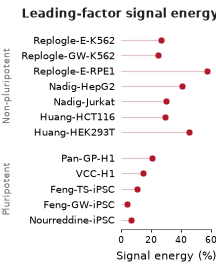

In [2]:
energy = pd.read_csv(FIRST_FACTOR / "first_svd_global_trend_strength_comparison_se_adjusted.csv")
energy = energy[energy["perturbation_set"].eq("L1_selected")].set_index("dataset").reindex(DATASETS)
signal = energy["se_adjusted_rank1_energy_percent"].to_numpy(float)

use_panel_style(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "font.size": 7.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.65,
    }
)
figure, axis = plt.subplots(figsize=(50.0 / 25.4, 62.0 / 25.4), facecolor="white")
figure.subplots_adjust(left=0.560, right=0.975, bottom=0.145, top=0.885)

# Fig 1a/1c order, with a gap between the two contexts.
y_non_pluripotent = np.arange(7, dtype=float)
y_pluripotent = np.arange(5, dtype=float) + 7.0 + 0.70
y_positions = np.concatenate((y_non_pluripotent, y_pluripotent))

# Leave a label gutter to the right of the longest lollipop.
upper = max(60.0, float(np.ceil((signal.max() + 2.0) / 10.0) * 10.0))
for y_position, value in zip(y_positions, signal):
    axis.hlines(y_position, 0.0, value, color="#D39AA3", linewidth=0.78, alpha=0.58, zorder=2)
    axis.scatter(value, y_position, s=20, color="#B2182B", edgecolor="white", linewidth=0.30, zorder=3)

axis.set_xlim(0.0, upper)
axis.set_ylim(y_positions[-1] + 0.62, -0.62)
axis.set_yticks(y_positions, LABELS)
axis.tick_params(axis="y", labelsize=6.25, length=0, pad=4.2)
axis.set_xticks(np.arange(0.0, upper + 0.1, 20.0))
axis.tick_params(axis="x", labelsize=6.0, length=2.2, width=0.55, pad=2.3)
axis.set_xlabel("Signal energy (%)", fontsize=7.0, labelpad=3.5)
figure.suptitle(
    "Leading-factor signal energy",
    x=0.555,
    y=0.970,
    fontsize=8.1,
    fontweight="bold",
    color=TEXT_COLOR,
)
axis.set_axisbelow(True)
axis.grid(False)
for side in ("top", "right", "left"):
    axis.spines[side].set_visible(False)
axis.spines["bottom"].set_color("#7A7F84")
axis.spines["bottom"].set_linewidth(0.65)

# Context labels, centred on each group of rows, left of the dataset names.
figure.canvas.draw()
data_to_figure = figure.transFigure.inverted().transform
for label, rows in (("Non-pluripotent", y_non_pluripotent), ("Pluripotent", y_pluripotent)):
    y_center = data_to_figure(axis.transData.transform((0.0, float(rows.mean()))))[1]
    figure.text(
        0.030,
        y_center,
        label,
        rotation=90,
        rotation_mode="anchor",
        ha="center",
        va="center",
        fontsize=5.7,
        color="#666B70",
    )

show_inline(figure)
figure.savefig(FIGURES / "leading_factor_signal_energy.pdf", facecolor="white")
plt.close(figure)

pd.DataFrame(
    {
        "dataset": LABELS,
        "context": np.where(np.arange(len(LABELS)) < N_NON_PLURIPOTENT, "Non-pluripotent", "Pluripotent"),
        "signal_energy_percent": signal,
    }
).to_csv(DATA / "leading_factor_signal_energy.csv", index=False)

## Fig. 1b right — leading-factor loading by target pan-essentiality

Mean within-dataset percentile of the all-QC leading-factor loading |u1| in ten equal-count bins of the target's pan-essentiality score, over the targets scored in every DepMap line. Loadings: `FIRST_FACTOR` (`first_svd_perturbation_loadings_all_datasets.csv.gz`), from `2_global_trend/fit_first_factor.py`; targets: `STRENGTH_SCORES` (`perturbation_strength_all_datasets.csv`), from `1_preprocessing/compute_perturbation_strength.py`; scores: `PAN_ESSENTIALITY`, from `2_global_trend/compute_pan_essentiality_score.py` (with the reference results, its paper copy `PAPER_PAN_ESSENTIALITY`).

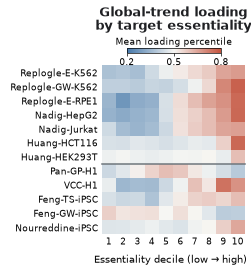

In [3]:
N_DECILES = 10

loadings = pd.read_csv(FIRST_FACTOR / "first_svd_perturbation_loadings_all_datasets.csv.gz")
targets = pd.read_csv(STRENGTH_SCORES / "perturbation_strength_all_datasets.csv")
essentiality = pd.read_csv(PAN_ESSENTIALITY)
# Every QC-passing perturbation of either table, with the score of its target
# (exact symbol match).
table = loadings.merge(
    targets[["dataset", "perturbation", "target_gene"]], on=["dataset", "perturbation"], how="outer"
).merge(essentiality, left_on="target_gene", right_on="gene_symbol", how="left")
# |u1| is ranked over all QC-passing perturbations of a dataset; only the
# targets scored in every DepMap line are then binned by essentiality.
table["loading_percentile"] = table.groupby("dataset", sort=False)["absolute_u1"].rank(
    method="average", pct=True
)
eligible = table[table["n_lines_screened"].eq(essentiality["n_lines_screened"].max())]

bins = []
for dataset in DATASETS:
    subset = eligible[eligible["dataset"].eq(dataset)].sort_values(
        ["pan_essentiality_score", "perturbation"], kind="mergesort"
    )
    # Stable equal-count bins; tied scores are ordered by perturbation name.
    n_rows = len(subset)
    decile = np.floor(np.arange(n_rows, dtype=float) * N_DECILES / n_rows).astype(int) + 1
    mean = subset.groupby(decile)["loading_percentile"].mean()
    bins.append(
        pd.DataFrame(
            {
                "dataset": paper_name(dataset),
                "essentiality_decile": mean.index,
                "mean_loading_percentile": mean.to_numpy(),
            }
        )
    )
loading_bins = pd.concat(bins, ignore_index=True)
matrix = loading_bins["mean_loading_percentile"].to_numpy(float).reshape(len(DATASETS), N_DECILES)

use_panel_style(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "font.size": 7.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.60,
    }
)
figure, axis = plt.subplots(figsize=(58.0 / 25.4, 62.0 / 25.4), facecolor="white")
figure.subplots_adjust(left=0.405, right=0.975, bottom=0.125, top=0.755)

image = axis.imshow(
    matrix,
    cmap=colors.LinearSegmentedColormap.from_list("loading_percentile", ["#4477AA", "#F7F7F4", "#C4523D"]),
    norm=colors.TwoSlopeNorm(vmin=0.20, vcenter=0.50, vmax=0.80),
    interpolation="nearest",
    aspect="auto",
    origin="upper",
    rasterized=False,
)
axis.set_xticks(np.arange(N_DECILES))
axis.set_xticklabels(np.arange(1, N_DECILES + 1), fontsize=6.0)
axis.set_yticks(np.arange(len(DATASETS)))
axis.set_yticklabels(LABELS, fontsize=5.7)
axis.tick_params(axis="x", length=0, pad=2.0)
axis.tick_params(axis="y", length=0, pad=2.5)
axis.set_xlabel("Essentiality decile (low → high)", fontsize=6.8, labelpad=4.0)
# Shift the long label slightly left so it stays inside the 58-mm canvas.
axis.xaxis.set_label_coords(0.48, -0.12)

# Non-pluripotent / pluripotent divider.
axis.axhline(N_NON_PLURIPOTENT - 0.5, color="#6F777D", linewidth=1.0, clip_on=False, zorder=4)
for spine in axis.spines.values():
    spine.set_visible(False)

figure.suptitle(
    "Global-trend loading\nby target essentiality",
    x=0.69,
    y=0.975,
    ha="center",
    va="top",
    fontsize=8.3,
    fontweight="bold",
    color=TEXT_COLOR,
    linespacing=1.05,
)
colorbar_axis = figure.add_axes([0.505, 0.800, 0.375, 0.020])
colorbar = figure.colorbar(image, cax=colorbar_axis, orientation="horizontal")
colorbar.set_ticks([0.20, 0.50, 0.80])
colorbar.set_ticklabels(["0.2", "0.5", "0.8"])
colorbar.ax.tick_params(labelsize=5.6, length=1.8, width=0.45, pad=1.4)
colorbar.outline.set_linewidth(0.45)
colorbar.set_label("Mean loading percentile", fontsize=6.1, labelpad=2.0)
colorbar.ax.xaxis.set_label_position("top")

show_inline(figure)
figure.savefig(FIGURES / "loading_by_pan_essentiality.pdf", facecolor="white")
plt.close(figure)

loading_bins.to_csv(DATA / "loading_percentile_by_pan_essentiality_decile.csv", index=False)

## Supplementary Fig. S1d — leading-factor concordance

Coupled leading-factor cosine cos(u1, u1') · cos(v1, v1') of the L1-selected fits, per dataset pair over the shared perturbations and primary genes; the product does not depend on the sign of either factor. Loadings: `FIRST_FACTOR` (`first_svd_L1_selected_{perturbation,gene}_loadings_all_datasets.csv.gz`), from `2_global_trend/fit_first_factor.py`.

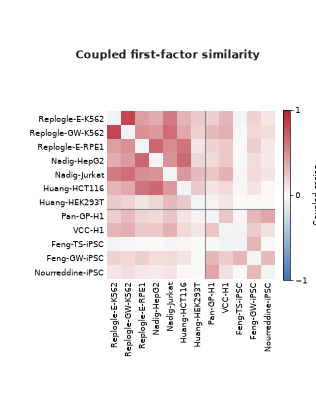

In [4]:
def pairwise_cosines(loadings, key, column):
    """Cosine of the loadings of every dataset pair over their shared elements."""
    subsets = [loadings.loc[loadings["dataset"].eq(dataset), [key, column]] for dataset in DATASETS]
    cosine = np.ones((len(DATASETS), len(DATASETS)))  # unit diagonal
    for i in range(len(DATASETS)):
        for j in range(i + 1, len(DATASETS)):
            shared = subsets[i].merge(subsets[j], on=key)
            a = shared[f"{column}_x"].to_numpy(float)
            b = shared[f"{column}_y"].to_numpy(float)
            cosine[i, j] = cosine[j, i] = np.dot(a, b) / float(np.linalg.norm(a) * np.linalg.norm(b))
    return cosine


u_cosine = pairwise_cosines(
    pd.read_csv(FIRST_FACTOR / "first_svd_L1_selected_perturbation_loadings_all_datasets.csv.gz"),
    "perturbation",
    "left_singular_vector_u1",
)
v_cosine = pairwise_cosines(
    pd.read_csv(FIRST_FACTOR / "first_svd_L1_selected_gene_loadings_all_datasets.csv.gz"),
    "gene",
    "right_singular_vector_v1",
)
keys = [slug(dataset) for dataset in DATASETS]
coupled = pd.DataFrame(u_cosine * v_cosine, index=keys, columns=keys)

use_panel_style(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "font.size": 5.4,
        "axes.titlesize": 7.2,
        "xtick.labelsize": 5.2,
        "ytick.labelsize": 5.2,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
figure = plt.figure(figsize=(73.0 * MM, 92.0 * MM), facecolor="white")
axis = figure.add_axes((0.34, 0.295, 0.53, 0.428), label="coupled_heatmap")
axis.set_gid("coupled_heatmap")
colorbar_axis = figure.add_axes((0.895, 0.295, 0.022, 0.428), label="colorbar")

cmap = colors.LinearSegmentedColormap.from_list(
    "coupled_similarity", ("#3F72B5", "#FBFAF7", "#B51F2E"), N=256
)
cmap.set_bad("#F2F3F4")
values = coupled.to_numpy(float)
axis.set_facecolor("#F2F3F4")
image = axis.imshow(
    np.ma.array(values, mask=np.eye(len(values), dtype=bool)),
    cmap=cmap,
    norm=colors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0),
    interpolation="nearest",
    aspect="equal",
    origin="upper",
)

positions = np.arange(len(DATASETS))
axis.set_xticks(positions)
axis.set_yticks(positions)
axis.set_xticklabels(LABELS)
axis.set_yticklabels(LABELS)
plt.setp(axis.get_xticklabels(), rotation=90, rotation_mode="anchor", ha="right", va="center", fontsize=5.2)
plt.setp(axis.get_yticklabels(), rotation=0, rotation_mode="anchor", ha="right", fontsize=5.2)
axis.tick_params(axis="both", which="both", length=0, pad=2.2)
axis.set_xlim(-0.5, len(DATASETS) - 0.5)
axis.set_ylim(len(DATASETS) - 0.5, -0.5)
axis.grid(False)
for spine in axis.spines.values():
    spine.set_visible(False)
axis.axvline(N_NON_PLURIPOTENT - 0.5, color="#737A80", linewidth=0.75, alpha=0.78, zorder=5)
axis.axhline(N_NON_PLURIPOTENT - 0.5, color="#737A80", linewidth=0.75, alpha=0.78, zorder=5)

colorbar = figure.colorbar(image, cax=colorbar_axis, ticks=[-1.0, 0.0, 1.0])
colorbar.outline.set_linewidth(0.45)
colorbar.ax.tick_params(labelsize=5.2, length=1.8, width=0.45, pad=1.8)
colorbar.set_label("Coupled cosine", fontsize=5.5, labelpad=3.0)
figure.suptitle(
    "Coupled first-factor similarity",
    x=0.53,
    y=0.875,
    fontsize=7.2,
    fontweight="bold",
    color=TEXT_COLOR,
)

figure.canvas.draw()
show_inline(figure)
figure.savefig(FIGURES / "leading_factor_concordance.pdf", facecolor="white")
plt.close(figure)

# The displayed matrix (unit diagonal), labelled as in the frozen results (utils.paths.slug).
coupled.to_csv(DATA / "leading_factor_concordance_matrix.csv")